#Trabalho 3 - Métodos Numéricos



In [1]:
import numpy as np
import cmath
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Questão 1

###Usando os conceitos vistos em sala de aula, determine o número de raízes reais positivas, o número de raízes reais negativas e o número de raízes complexas de f(x). Você deve determinar o número de raízes sem encontrar as raízes, apenas usando os resultados estudados.

---


Vamos usar a Regra de Sinais de Descartes para determinar o número de raízes reais positivas, negativas e complexas de $f(x) = 2x^3 + 3x^2 + 0x +5x^0$. Observe que não há nenhuma troca de sinal e portanto $p = v = 0$. Para $f(-x) = -2x^3 + 3x^2 - 0x +5x^0$ temos apenas uma mudança de sinal. Como $v - neg$ precisa ser par e não negativo, $v = neg = 1$. Por fim, concluímos que existem 0 raízes reais positivas e 1 raiz real negativa. Note que $deg(f) = 3$. Dessa forma, existem 2 raízes complexas conjugadas.

In [2]:
# Coeficientes de f(x) = 2x^3 + 3x^2 + 0x + 5 (ordem decrescente)
coefs = [2, 3, 0, 5]
grau = len(coefs) - 1

def variacoes_sinal(coefs):
    """Conta mudanças de sinal em uma lista, ignorando zeros."""
    sinais = [c for c in coefs if c != 0]
    v = sum(1 for i in range(len(sinais)-1) if sinais[i] * sinais[i+1] < 0)
    return v

# Raízes positivas: analisar f(x)
v_pos = variacoes_sinal(coefs)
possiveis_pos = list(range(v_pos, -1, -2))  # v, v-2, v-4, ...

# Raízes negativas: analisar f(-x)
# Para f(-x), basta alternar o sinal dos coeficientes de grau ímpar
coefs_neg = [c * ((-1)**i) for i, c in enumerate(reversed(coefs))]
coefs_neg = list(reversed(coefs_neg))
v_neg = variacoes_sinal(coefs_neg)
possiveis_neg = list(range(v_neg, -1, -2))

print("=" * 55)
print("QUESTÃO 1 — Regra dos Sinais de Descartes")
print("=" * 55)
print(f"\nf(x)  → coeficientes: {coefs}")
print(f"f(-x) → coeficientes: {coefs_neg}")
print(f"\nVariações de sinal em f(x):   v = {v_pos}")
print(f"Variações de sinal em f(-x):  v = {v_neg}")
print(f"\nPossíveis raízes positivas: {possiveis_pos}")
print(f"Possíveis raízes negativas: {possiveis_neg}")

# Como v_pos=0, exatamente 0 positivas; v_neg=1, exatamente 1 negativa
n_pos = possiveis_pos[0]  # único valor possível
n_neg = possiveis_neg[0]  # único valor possível
n_comp = grau - n_pos - n_neg

print(f"\n{'─'*55}")
print(f"Raízes reais positivas : {n_pos}")
print(f"Raízes reais negativas : {n_neg}")
print(f"Raízes complexas       : {n_comp} (par conjugado)")
print(f"{'─'*55}")

QUESTÃO 1 — Regra dos Sinais de Descartes

f(x)  → coeficientes: [2, 3, 0, 5]
f(-x) → coeficientes: [-2, 3, 0, 5]

Variações de sinal em f(x):   v = 0
Variações de sinal em f(-x):  v = 1

Possíveis raízes positivas: [0]
Possíveis raízes negativas: [1]

───────────────────────────────────────────────────────
Raízes reais positivas : 0
Raízes reais negativas : 1
Raízes complexas       : 2 (par conjugado)
───────────────────────────────────────────────────────




---



##Questão 2
###Determine um raio $r1$ de forma que haja pelo menos uma raiz de $f(x)$ na região circular definida por $|x| ≤ r1$. Além disso, determine um raio $r2$, com $r2 > r1$, de forma que todas as raízes de $f(x)$ se encontrem na região circular definida por $|x| ≤ r2$. Você deve determinar $r1$ e $r2$ sem encontrar as raízes, apenas usando os resultados estudados.



---



Usando o Teorema 1 dos slides da aula 4, temos o seguinte: $n = 3; a_0 = 5; a_1 = 0; a_n = a_3 = 2$. Com isso, é possível afirmar que $\rho_1 = n⋅\frac{|a_0|}{|a_1|}$ é indefinido. Nesse caso, usamos apenas $\rho_n = \sqrt[n]{\frac{|a_0|}{|a_1|}} = \sqrt[3]{\frac{5}{2}} ≈ 1,357$. Portanto, $r_1 ≈ 1,357$ e há pelo menos uma raiz com $|x| \leq r_1$.

Pelo Teorema 2 dos slides da aula 4, temos que:
$$
\
r_2 = 1 + \max_{0 \leq k \leq n-1} \frac{|a_k|}{|a_n|}
    = 1 + \max\left\{\frac{|5|}{2},\ \frac{|0|}{2},\ \frac{|3|}{2}\right\}
    = 1 + \max\{2{,}5,\ 0,\ 1{,}5\}
    = 1 + 2{,}5
    = 3{,}5
\
$$
Dessa maneira, com $r_2 = 3,5$, todas as raízes satisfazem $|x| \leq 3,5$ e $r_2 > r_1$.

QUESTÃO 2 — Localização das Raízes

Teorema 1 (pelo menos uma raiz dentro do círculo):
  ρ_n = (|a0|/|an|)^(1/n) = (5/2)^(1/3) = 1.3572
  → r1 = 1.3572  (há pelo menos uma raiz com |x| ≤ r1)

Teorema 2 (todas as raízes dentro do círculo):
  |a0|/|a3| = 5/2 = 2.5000
  |a1|/|a3| = 0/2 = 0.0000
  |a2|/|a3| = 3/2 = 1.5000
  max = 2.5000
  → r2 = 1 + 2.5000 = 3.5000  (todas as raízes com |x| ≤ r2)

  Verificação: r2 (3.5000) > r1 (1.3572) ✓


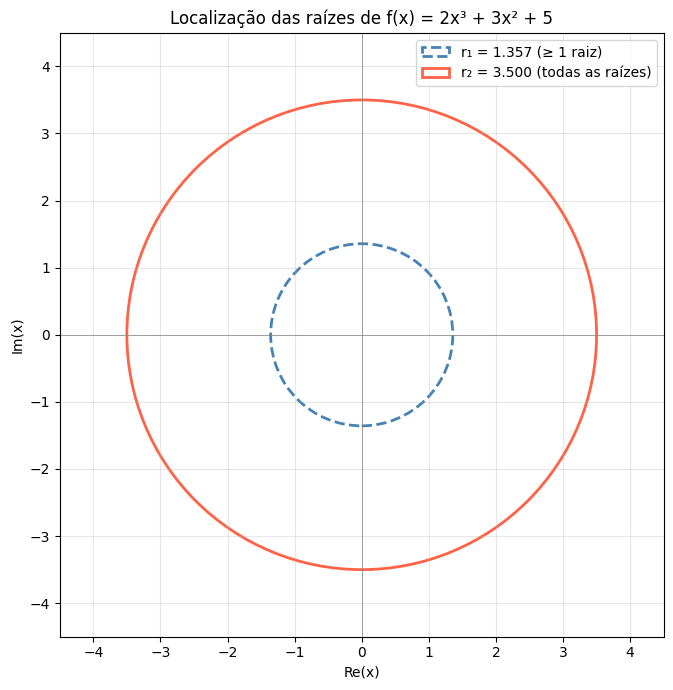

In [7]:
# f(x) = 2x^3 + 3x^2 + 0x + 5
# Coeficientes indexados: a0=5, a1=0, a2=3, a3=2
a = {3: 2, 2: 3, 1: 0, 0: 5}
n = 3

print("=" * 55)
print("QUESTÃO 2 — Localização das Raízes")
print("=" * 55)

# Teorema 1: rho_n = (|a0|/|an|)^(1/n)
# (rho_1 = n*|a0|/|a1| não se aplica pois a1=0)
rho_n = (abs(a[0]) / abs(a[n])) ** (1/n)
r1 = rho_n

print(f"\nTeorema 1 (pelo menos uma raiz dentro do círculo):")
print(f"  ρ_n = (|a0|/|an|)^(1/n) = ({abs(a[0])}/{abs(a[n])})^(1/{n}) = {r1:.4f}")
print(f"  → r1 = {r1:.4f}  (há pelo menos uma raiz com |x| ≤ r1)")

# Teorema 2: r = 1 + max(|ak|/|an|) para k de 0 a n-1
razoes = {k: abs(a[k])/abs(a[n]) for k in range(n)}
max_razao = max(razoes.values())
r2 = 1 + max_razao

print(f"\nTeorema 2 (todas as raízes dentro do círculo):")
for k, v in razoes.items():
    print(f"  |a{k}|/|a{n}| = {abs(a[k])}/{abs(a[n])} = {v:.4f}")
print(f"  max = {max_razao:.4f}")
print(f"  → r2 = 1 + {max_razao:.4f} = {r2:.4f}  (todas as raízes com |x| ≤ r2)")
print(f"\n  Verificação: r2 ({r2:.4f}) > r1 ({r1:.4f}) ✓")

# Gráfico dos círculos de localização
fig, ax = plt.subplots(figsize=(7, 7))
circle1 = plt.Circle((0, 0), r1, color='steelblue', fill=False,
                      linewidth=2, linestyle='--', label=f'r₁ = {r1:.3f} (≥ 1 raiz)')
circle2 = plt.Circle((0, 0), r2, color='tomato', fill=False,
                      linewidth=2, label=f'r₂ = {r2:.3f} (todas as raízes)')
ax.add_patch(circle1)
ax.add_patch(circle2)
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4.5, 4.5)
ax.set_aspect('equal')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Re(x)')
ax.set_ylabel('Im(x)')
ax.set_title('Localização das raízes de f(x) = 2x³ + 3x² + 5')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



---



##Questão 3
###Implemente o Método Muller para encontrar as raízes da função f(x). Você deve encontrar todas as raízes reais, mas não precisa encontrar todas as raízes complexas, pois elas ocorrem aos pares conjugados. Basta encontrar metade das raízes complexas. Você deve escolher as estimativas iniciais x0, x1 e x2 que você achar adequado, de acordo com os resultados das Questões 1 e 2.
###Use como critério de parada: εa < εS. Seu código deve gerar os seguintes resultados de saída:
###- Valor de εa a cada iteração
###- Valor de |f(x)| a cada iteração
###- Número de iterações



---



In [8]:
def f(x):
    """Função alvo: f(x) = 2x^3 + 3x^2 + 5"""
    return 2*x**3 + 3*x**2 + 5

def muller(x0, x1, x2, es=1e-6, max_iter=100, label=""):
    """
    Método de Müller para encontrar raízes de f(x).
    Retorna a raiz encontrada e o histórico de iterações.
    """
    print(f"\n{'='*60}")
    print(f"Método de Müller — Busca: {label}")
    print(f"Estimativas iniciais: x0={x0}, x1={x1}, x2={x2}")
    print(f"{'='*60}")
    print(f"{'Iter':>4} | {'x3':>22} | {'ea (%)':>12} | {'|f(x3)|':>14}")
    print("-"*60)

    historico = []
    x0, x1, x2 = complex(x0), complex(x1), complex(x2)

    for i in range(1, max_iter + 1):
        h0 = x1 - x0
        h1 = x2 - x1
        d0 = (f(x1) - f(x0)) / h0
        d1 = (f(x2) - f(x1)) / h1

        a = (d1 - d0) / (h1 + h0)
        b = a * h1 + d1
        c = f(x2)

        disc = cmath.sqrt(b**2 - 4*a*c)

        # Escolhe o sinal que maximiza o módulo do denominador
        if abs(b + disc) >= abs(b - disc):
            x3 = x2 + (-2*c) / (b + disc)
        else:
            x3 = x2 + (-2*c) / (b - disc)

        ea = abs((x3 - x2) / x3) * 100 if x3 != 0 else float('inf')
        fx3 = abs(f(x3))

        historico.append((i, x3, ea, fx3))

        # Formata x3 de forma legível
        if abs(x3.imag) < 1e-10:
            x3_str = f"{x3.real:>22.10f}"
        else:
            x3_str = f"{x3.real:.6f}{x3.imag:+.6f}j"
            x3_str = f"{x3_str:>22}"

        print(f"{i:>4} | {x3_str} | {ea:>12.6f} | {fx3:>14.8f}")

        if ea < es:
            print(f"\n Convergiu em {i} iteração(ões). Critério: εa < εs = {es}")
            break

        x0, x1, x2 = x1, x2, x3

    raiz = x3
    if abs(raiz.imag) < 1e-8:
        raiz = raiz.real
    print(f"\nRaiz encontrada: {raiz}")
    print(f"|f(raiz)| = {abs(f(complex(raiz))):.2e}")
    return raiz, historico


# ── Execução ──────────────────────────────────────────────
# Q1 mostrou: 0 raízes positivas, 1 negativa, 2 complexas
# Q2 mostrou: todas as raízes satisfazem |x| <= 3.5
# A raiz real está no semiplano negativo → x0,x1,x2 negativos

es = 1e-4  # critério de parada

# Busca 1: raiz real negativa
raiz_real, hist_real = muller(-3.5, -2.5, -1.5, es=es, label="Raiz real negativa")

# Busca 2: raiz complexa (ponto inicial com parte imaginária)
# Com pontos reais o método pode convergir para complexas,
# mas para garantir, usamos uma perturbação imaginária leve
raiz_comp, hist_comp = muller(0.5+0.5j, 1.0+1.0j, 0.5+1.5j, es=es, label="Raiz complexa")


Método de Müller — Busca: Raiz real negativa
Estimativas iniciais: x0=-3.5, x1=-2.5, x2=-1.5
Iter |                     x3 |       ea (%) |        |f(x3)|
------------------------------------------------------------
   1 |          -2.1250000000 |    29.411765 |     0.64453125
   2 |          -2.0802360146 |     2.151871 |     0.02180563
   3 |          -2.0786233225 |     0.077585 |     0.00008655
   4 |          -2.0786168884 |     0.000310 |     0.00000000
   5 |          -2.0786168885 |     0.000000 |     0.00000000

 Convergiu em 5 iteração(ões). Critério: εa < εs = 0.0001

Raiz encontrada: -2.0786168885087584
|f(raiz)| = 3.55e-15

Método de Müller — Busca: Raiz complexa
Estimativas iniciais: x0=(0.5+0.5j), x1=(1+1j), x2=(0.5+1.5j)
Iter |                     x3 |       ea (%) |        |f(x3)|
------------------------------------------------------------
   1 |     0.310428+1.085320j |    40.391561 |     0.38984083
   2 |     0.287017+1.058047j |     3.278590 |     0.02522772
   3 

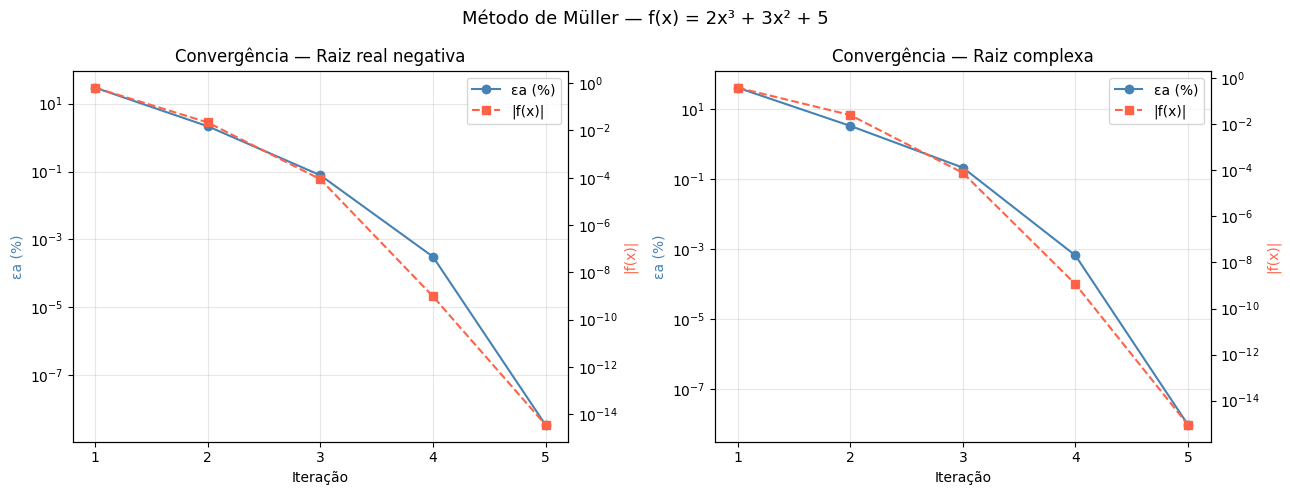

In [5]:
# ── Gráfico de convergência ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, hist, titulo in zip(
    axes,
    [hist_real, hist_comp],
    ["Raiz real negativa", "Raiz complexa"]
):
    iters = [h[0] for h in hist]
    ea_vals = [h[2] for h in hist]
    fx_vals = [h[3] for h in hist]

    ax2 = ax.twinx()
    l1, = ax.semilogy(iters, ea_vals, 'o-', color='steelblue', label='εa (%)')
    l2, = ax2.semilogy(iters, fx_vals, 's--', color='tomato', label='|f(x)|')
    ax.set_xlabel('Iteração')
    ax.set_ylabel('εa (%)', color='steelblue')
    ax2.set_ylabel('|f(x)|', color='tomato')
    ax.set_title(f'Convergência — {titulo}')
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[l1, l2], loc='upper right')
    ax.set_xticks(iters)

plt.suptitle('Método de Müller — f(x) = 2x³ + 3x² + 5', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# ── Verificação com numpy ──────────────────────────────────
print("\nVerificação das raízes (numpy.roots):")
raizes_np = np.roots([2, 3, 0, 5])
for i, r in enumerate(raizes_np):
    print(f"  Raiz {i+1}: {r}  →  |f(r)| = {abs(f(r)):.2e}")


Verificação das raízes (numpy.roots):
  Raiz 1: (-2.0786168885087606+0j)  →  |f(r)| = 2.84e-14
  Raiz 2: (0.28930844425437974+1.0578390522729841j)  →  |f(r)| = 5.40e-15
  Raiz 3: (0.28930844425437974-1.0578390522729841j)  →  |f(r)| = 5.40e-15




---




##Questão 4
###Justifique as suas escolhas para as estimativas iniciais x0, x1 e x2.



---



Pelos resultados anteriores, sabemos que a única raiz real é negativa e está dentro do círculo de raio 3,5. Um ponto de partida razoável é escolher $x_1, x_2, x_3$​ como três valores negativos próximos entre si dentro desse intervalo, por exemplo $x_0 = -2,5$, $x_1 = -1,5$, $x_2 = -0,5$. Essa escolha cobre a região negativa onde a raiz real foi prevista existir, e distribui os três pontos de forma que a parábola de Müller tenha curvatura significativa para convergir à raiz.



---



##Questão 5
### Discuta por que o Método de Müller pode ser vantajoso em relação ao Método da Secante para polinômios de grau elevado.



---



O Método da Secante aproxima $f(x)$ por uma reta entre dois pontos. Como uma reta não tem raízes complexas, ele só consegue convergir para raízes reais. O Método de Müller usa três pontos para ajustar uma parábola, e ao aplicar a fórmula quadrática para encontrar suas raízes, o discriminante $\Delta = b^2 - 4ac$ pode ser negativo, produzindo naturalmente raízes complexas. Além disso, para polinômios de grau elevado com muitas raízes complexas, o Método de Müller é essencial pois os métodos intervalares e abertos clássicos simplesmente não funcionam nesses casos.



---



##Questão 6
### Por que o método pode convergir para raízes complexas mesmo quando os pontos iniciais são reais?



---



Porque o Método de Müller opera algebricamente com a fórmula quadrática, e os coeficientes $a, b, c$ da parábola são calculados a partir de valores reais de $f$. Quando o discriminante $\Delta = b^2 - 4ac <0 $, a raiz quadrada torna-se imaginária e o método naturalmente passa a operar no plano complexo.



---

